# DCGAN

## Imports

In [1]:
#%matplotlib inline
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors 
from matplotlib.ticker import FuncFormatter
import json
import time
import copy



from IPython.display import HTML, display, Image as Img
from PIL import Image
import cv2
from torch.utils.data import DataLoader, TensorDataset, Dataset



# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  999


## Parameters

In [2]:
# Root directory for dataset
# use of os.path.join to maximize campatibility beetween different Operating Systems
datarootImagenette = os.path.join("data", "databases", "imagenette2")
print(datarootImagenette)
datarootImagewoof=  os.path.join("data", "databases", "imagewoof2")
print(datarootImagewoof)
GENERATED = os.path.join("data", "generated")
PLOTS = "plots"
MODELS = "models"
TRANSFORMED_DATASET = "transformed_datasets"

# Number of workers for dataloader
workers = 16

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

data\databases\imagenette2
data\databases\imagewoof2


Imagenette is a subset of 10 easily classified classes from Imagenet (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute).

Imagewoof is a subset of 10 classes from Imagenet that aren't so easy to classify, since they're all dog breeds. The breeds are: Australian terrier, Border terrier, Samoyed, Beagle, Shih-Tzu, English foxhound, Rhodesian ridgeback, Dingo, Golden retriever, Old English sheepdog.

In [3]:
classificatorImagenette = {
    "tench": "n01440764", # Type of fish
    "English springer": "n02102040", # Type of dog
    "cassette player": "n02979186", 
    "chain saw": "n03000684",
    "church": "n03028079",
    "French horn": "n03394916",
    "garbage truck": "n03417042",
    "gas pump": "n03425413",
    "golf ball": "n03445777",
    "parachute": "n03888257"
}
classificatorImagewoof = {
    "Australian terrier": "n02086240", 
    "Border terrier": "n02087394", 
    "Samoyed": "n02088364", 
    "Beagle": "n02089973",
    "Shih-Tzu": "n02093754",
    "English foxhound": "n02096294",
    "Rhodesian ridgeback": "n02099601",
    "Dingo": "n02105641",
    "Golden retriever": "n02111889",
    "Old English sheepdog": "n02115641"
}


## Show examples of Images
Functions to make the dataset visuabel and make a better understanding of the data we are gonna use

In [4]:
def show_images_dataset(dataroot, folderClassificator):
    """ images = []
    titles = []
    # Itera a través de cada categoría en el clasificador
    for key in folderClassificator:
        first_image_path = None
        folder_path = os.path.join(dataroot, "train", folderClassificator[key])

        titles.append(f"{key}, Samples: {len([_ for _ in os.listdir(folder_path)])}")

        # Encuentra la primera imagen en la carpeta
        for file_name in os.listdir(folder_path):
            if file_name.endswith(('.jpg', '.png', '.jpeg', '.JPG', '.PNG', '.JPEG')):
                first_image_path = os.path.join(folder_path, file_name)
                break  # Detenemos el bucle en la primera imagen encontrada

        # Si se encontró la imagen, la añadimos a la lista
        if first_image_path:
            image = Image.open(first_image_path)
            images.append(image)
            
        else:
            print(f"No se encontró ninguna imagen en la carpeta para {key}")


    # Configuración del layout para mostrar las imágenes en una cuadrícula de 3 columnas
    num_images = len(images)
    num_rows = (num_images + 2) // 3  # Redondea hacia arriba para completar filas

    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows), constrained_layout=True)  # Ocupa todo el ancho con ajuste automático

    # Dibuja cada imagen en la cuadrícula
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(images[i])
            ax.set_title(titles[i], fontsize=8)
            ax.axis('off')  # Quita los ejes
        else:
            ax.axis('off')  # Oculta celdas vacías

    plt.show(fig) """

def most_common(lst):
    return max(set(lst), key=lst.count)

def get_image_dimension(path):
    im = cv2.imread(path)
    h, w, _ = im.shape
    return h, w

# Under construction
def create_heapmap_from_dimension(widths, heights):
    total = len(widths)
    dimensions = []
    maximum = max(max(widths), max(heights)) +1
    for _ in range(maximum):
        dimensions.append([])
    for i in range(maximum):
        for _ in range(maximum):
            dimensions[i].append(0)

    
    for i in range(total):
        dimensions[widths[i]][heights[i]] += 1

    # dimensions = gaussian_filter(dimensions, sigma=10)

    def heatmap2d(arr: np.ndarray):
        plt.imshow(arr, cmap='viridis')
        plt.colorbar()
        plt.show()

    heatmap2d(dimensions)

def show_dimensions_dataset(dataroot, folderClassificator, saveFile=None):
    imagesSize = []
    # Itera a través de cada categoría en el clasificador
    for key in folderClassificator:
        image_path = None
        folder_path = os.path.join(dataroot, "train", folderClassificator[key])
        # Save the dimension of every photo
        for file_name in os.listdir(folder_path):
            if file_name.endswith(('.jpg', '.png', '.jpeg', '.JPG', '.PNG', '.JPEG')):
                image_path = os.path.join(folder_path, file_name)
                imagesSize.append(get_image_dimension(image_path))


    widths, heights = zip(*imagesSize)
    
    # Min, max, most common and average widths
    dataWidths = [min(widths), max(widths), most_common(widths), round(sum(widths)/len(widths))]
    print(f"Width:\n -Lowest:  {dataWidths[0]}, Highest:  {dataWidths[1]}, Most common: {dataWidths[2]}, Average: {dataWidths[3]}")

    # Min, max, most common and average heights
    dataHeights = [min(heights), max(heights), most_common(heights), round(sum(heights)/len(heights))]
    print(f"Height:\n -Lowest:  {dataHeights[0]}, Highest:  {dataHeights[1]}, Most common: {dataHeights[2]}, Average: {dataHeights[3]}")


    # Guardar números y datos adicionales como JSON
    if saveFile is not None:
        with open(saveFile, "w") as file:
            json.dump({"widths": dataWidths, "heights": dataHeights}, file)

    # Create the scatter plot
    fig = plt.figure(figsize=(10, 6))
    plt.xscale('log')  # Logarithmic scale for x-axis
    plt.yscale('log')  # Logarithmic scale for y-axis
    plt.scatter(widths, heights, marker='o', s=100)  # s controls the size of points
    plt.title("Image Dimensions (log scale)")
    plt.xlabel("Width (pixels) (log scale)")
    plt.ylabel("Height (pixels) (log scale)")
    
    # Custom formatter to avoid scientific notation on both axes
    ax = plt.gca()
    ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.0f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.0f}'))

    # Annotate each point with its width and height
    for i, (w, h) in enumerate(imagesSize):
        plt.annotate(f"({w}, {h})", (w, h), textcoords="offset points", xytext=(5, 5), ha='center')

    plt.grid(True)
    if saveFile is not None:
        plt.savefig(saveFile+".png")
        print("Saved dimensions")
    plt.show()
    




def load_dimensions_dataset(dataroot, folderClassificator, output_path):
    """
    Load or compute dimensions dataset.

    Parameters:
        output_path (str): Path to save/load the output file.
        dataroot (str): Root directory of the dataset.
        folderClassificator (dict): Dictionary mapping class names to folder names.

    Returns:
        None
    """
    if not os.path.exists(output_path):
        # Compute and save dimensions dataset
        fig = show_dimensions_dataset(dataroot, folderClassificator, saveFile=output_path)
    else:
        # Load the precomputed dimensions dataset
        with open(output_path, "r") as file:
            loaded_data = json.load(file)

        dataWidths = loaded_data["widths"]
        print(f"Width:\n -Lowest:  {dataWidths[0]}, Highest:  {dataWidths[1]}, Most common: {dataWidths[2]}, Average: {dataWidths[3]}")

        dataHeights = loaded_data["heights"]
        print(f"Height:\n -Lowest:  {dataHeights[0]}, Highest:  {dataHeights[1]}, Most common: {dataHeights[2]}, Average: {dataHeights[3]}")

        display(Img(filename=output_path+".png"))

    


### imaginette 
#### Image examples
Show images of every type of imaginette

In [5]:
show_images_dataset(datarootImagenette,classificatorImagenette)

#### Distribution
Distribution of the images dimensions to see how the size looks like (A good idea to consider to wich size should be resized)

Width:
 -Lowest:  27, Highest:  4368, Most common: 375, Average: 408
Height:
 -Lowest:  50, Highest:  4288, Most common: 500, Average: 471


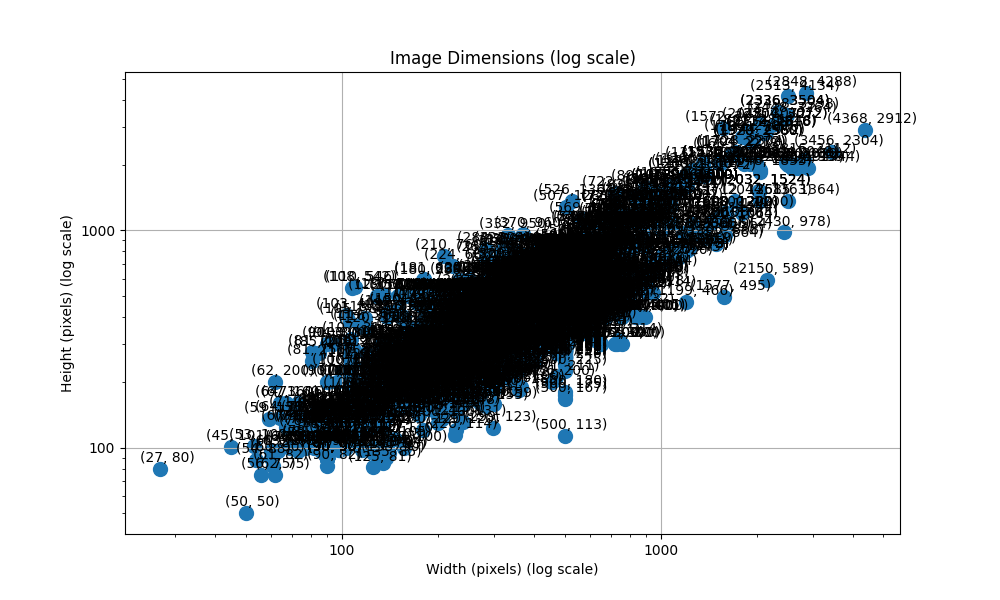

In [6]:
output_path = os.path.join(GENERATED, PLOTS, "imagenette_dimension_distribution")

load_dimensions_dataset(datarootImagenette,classificatorImagenette, output_path)


### imagewoof 
#### Image examples

Show all the images of imagewoof

In [7]:
show_images_dataset(datarootImagewoof,classificatorImagewoof)

#### Distribution

Width:
 -Lowest:  27, Highest:  4368, Most common: 375, Average: 408
Height:
 -Lowest:  50, Highest:  4288, Most common: 500, Average: 471


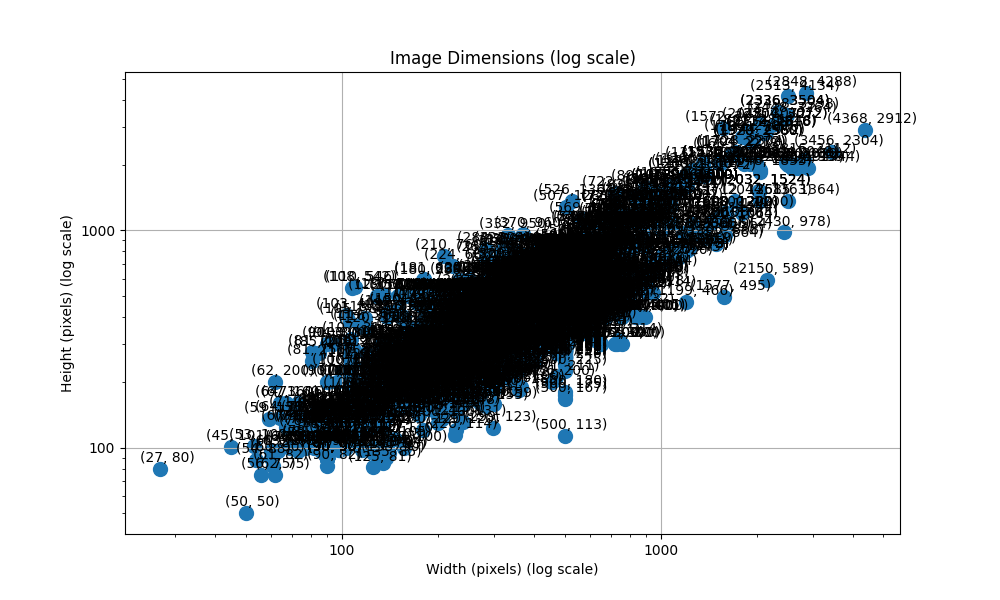

In [8]:
output_path = os.path.join(GENERATED, PLOTS, "imagewoof_dimension_distribution")

load_dimensions_dataset(datarootImagenette,classificatorImagenette, output_path)

Function to merge datasets

In [9]:
# Function to merge datasets

def merge_datasets(d1, d2):
    return TensorDataset(d1[:][0],d2[:])

## Create a dataset of the images.
- Add from every photo 4 instances (from rotating them, a rotated image contains the same information but would be different input for a Neuronal Network)
- Create the tensors with the category of each image

In [10]:
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

def show_images_grid(dataset, dataloader, titlePlot):# Plot some training images
        
    # Número total de imágenes en el dataset
    total_images = len(dataset)
    print(f"Total de imágenes en el dataset: {total_images}")

    # Número de batches por epoch en el dataloader
    batches_per_epoch = len(dataloader)
    print(f"Número de batches por epoch: {batches_per_epoch}")


    real_batch = next(iter(dataloader))
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(titlePlot)
    plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
    plt.show()


We use a class to create the dataset transforming the images when we create the dataset instead of when we iterate with them. Doing this we only transform the images once as we will train with the same dataset multiple models. The other way around the images where getting transformed every time we train a different model with the same dataset. 

In [11]:
class PreloadedImageFolder(dset.ImageFolder):
    def __init__(self, root, transform=None, target_transform=None):
        super().__init__(root, transform=None, target_transform=target_transform)
        
        # Aplicamos las transformaciones en __init__
        self.transform = transform
        self.preloaded_data = []
        
        for path, target in self.samples:
            sample = self.loader(path)  # Cargar la imagen
            if self.transform:
                sample = self.transform(sample)  # Aplicar la transformación
            self.preloaded_data.append((sample, target))  # Guardar la imagen transformada en memoria

    def __getitem__(self, index):
        return self.preloaded_data[index]  # Retornar la imagen preprocesada directamente


Create or load the transformed dataset

In [12]:
def load_dataset(dataroot, dataset_path):
    if os.path.exists(dataset_path):
        dataset = torch.load(dataset_path)
    else:
        start_time = time.time()
        dataset = PreloadedImageFolder(root=dataroot,
                                    transform=transforms.Compose([
                                    transforms.Resize(image_size),
                                    transforms.CenterCrop(image_size),
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                                ]))

        
        # show_images_grid(dataset, dataloaderIW,"Training Images Imagewoof")
        torch.save(dataset, dataset_path)
        print(f"\tTotal time creation of the dataset: {time.time() - start_time:.2f} seconds")
    return dataset

In [13]:
path_transformed_dataset = os.path.join(GENERATED, TRANSFORMED_DATASET)

# Imagewoof
path_datarootImagewoofTrain = os.path.join(datarootImagewoof, "train")
path_datasetImagewoof = os.path.join(path_transformed_dataset, "imagewoof.pt")
dataset = load_dataset(path_datarootImagewoofTrain, path_datasetImagewoof)
dataloaderIW = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=0)

# Imagenette
path_datarootImagenetteTrain = os.path.join(datarootImagenette, "train")
path_datasetImagenette = os.path.join(path_transformed_dataset, "imagenette.pt")
dataset = load_dataset(path_datarootImagenetteTrain, path_datasetImagenette)
dataloaderIN = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=0)

# show_images_grid(dataset, dataloaderIN,"Training Images Imagenette")


Initialize of the weights of the nodes

In [14]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Models

### Generator class

In [15]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. ``(ngf) x 32 x 32``
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

#### Initialization

In [16]:
# Create the generator
netG = Generator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


### Discriminator class

In [17]:
# Discriminator Code


class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True)
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

#### Initialization

In [18]:
# Create the Discriminator
netD = Discriminator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


### Optimizer

In [19]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.


### Different Models to train

In [20]:
def create_new_model(model_list, netD, netG, lr, dataloader, dataloaderName, num_epochs, betas=None, schedulerD=None, schedulerG=None):
    netD_copy = copy.deepcopy(netD)
    netG_copy = copy.deepcopy(netG)
    if betas is None:
        betas = (beta1, 0.999)
    
    optimizerD = optim.Adam(netD_copy.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(netG_copy.parameters(), lr=lr, betas=(beta1, 0.999))

    model_list.append([netD_copy, optimizerD, schedulerD, netG_copy, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs])


#### Imagiwoof Models

In [21]:
num_epochs = 50
dataloader = dataloaderIW
dataloaderName = "imagewoof"
modelsIW = [] # Append the differrent models of the Discriminator and Generator. Each append consist of (Discrimnator, OptimizerD, Generator, OptimizerG)

learning_rates = [
    0.05,
    0.01,
    0.005,
    0.001,
    0.0005,
    0.0001,
]

for lr in learning_rates:
    create_new_model(modelsIW, netD, netG, lr, dataloader, dataloaderName, num_epochs)



#### Imaginette models

In [22]:

num_epochs = 50
dataloader = dataloaderIN
dataloaderName = "imagenette"
modelsIN = []

"""
# ************ 1 ************
lr = 0.01
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
schedulerD = None
schedulerG = None
# Set the first train
modelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs])

 # ************ 2 ************
lr = 0.001
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
schedulerD = None
schedulerG = None
# Set the first train
modelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs])

# ************ 3 ************
# First hyperparamters Model
lr = 0.0001
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
schedulerD = None
schedulerG = None
# Set the first train
modelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs])

# ************ 4 ************
# First hyperparamters Model
lr = 0.00001
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
schedulerD = None
schedulerG = None
# Set the first train
modelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs])
 """

# ************ 6 ************
# First hyperparamters Model
""" lr = 0.0001
# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
schedulerD = torch.optim.lr_scheduler.StepLR(optimizerD, step_size=10, gamma=0.9)
schedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, step_size=10, gamma=0.9)
# Set the first train
modelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs]) 
"""


' lr = 0.0001\n# Setup Adam optimizers for both G and D\noptimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))\noptimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))\nschedulerD = torch.optim.lr_scheduler.StepLR(optimizerD, step_size=10, gamma=0.9)\nschedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, step_size=10, gamma=0.9)\n# Set the first train\nmodelsIN.append([netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs]) \n'

## Train Models

In [23]:
# Training Loop

def save_movel(model, optimizer, scheduler, epoch, losses, filename, img_list=None, trained_time=None):
    if scheduler is not None:
        scheduler = scheduler.state_dict()

    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler,
        'epoch': epoch,
        'losses': losses,
        'img_list': img_list,
        'trainedTime': trained_time,
    }, filename)


def train(num, netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, trained_epochs, num_epochs, D_losses=None, G_losses=None, img_list=None, trained_time=None):

    print(f"Training model: {num}.") 
    modelD_filename = os.path.join(GENERATED, MODELS, dataloaderName, f"{num}.ModelD")
    modelG_filename = os.path.join(GENERATED, MODELS, dataloaderName, f"{num}.ModelG")
    # Lists to keep track of progress
    if img_list is None:
        img_list = []
    if G_losses is None:
        G_losses = []
    if D_losses is None:
        D_losses = []

    if trained_time is None:
        trained_time = 0
    start_time = time.time()

    iters = 0
    # For each epoch
    for epoch in range(trained_epochs+1, num_epochs+1):
        # For each batch in the dataloader
        for i, data in enumerate(dataloader, 0):
            ############################
            # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
            ###########################
            ## Train with all-real batch
            netD.zero_grad()
            # Format batch
            real_cpu = data[0].to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
            # Forward pass real batch through D
            output = netD(real_cpu).view(-1)
            # Calculate loss on all-real batch
            errD_real = criterion(output, label)
            # Calculate gradients for D in backward pass
            errD_real.backward()
            D_x = output.mean().item()

            ## Train with all-fake batch
            # Generate batch of latent vectors
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            # Generate fake image batch with G
            fake = netG(noise)
            label.fill_(fake_label)
            # Classify all fake batch with D
            output = netD(fake.detach()).view(-1)
            # Calculate D's loss on the all-fake batch
            errD_fake = criterion(output, label)
            # Calculate the gradients for this batch, accumulated (summed) with previous gradients
            errD_fake.backward()
            D_G_z1 = output.mean().item()
            # Compute error of D as sum over the fake and the real batches
            errD = errD_real + errD_fake
            # Update D
            optimizerD.step()

            ############################
            # (2) Update G network: maximize log(D(G(z)))
            ###########################
            netG.zero_grad()
            label.fill_(real_label)  # fake labels are real for generator cost
            # Since we just updated D, perform another forward pass of all-fake batch through D
            output = netD(fake).view(-1)
            # Calculate G's loss based on this output
            errG = criterion(output, label)
            # Calculate gradients for G
            errG.backward()
            D_G_z2 = output.mean().item()
            # Update G
            optimizerG.step()

            # Save Losses for plotting later
            G_losses.append(errG.item())
            D_losses.append(errD.item())
            
            if (iters % 500 == 0) or ((epoch == num_epochs) and (i == len(dataloader)-1)):
                with torch.no_grad():
                    fake = netG(fixed_noise).detach().cpu()
                img = vutils.make_grid(fake, padding=2, normalize=True)
                img_list.append(img)
            
            iters += 1


        # Next epoch
        # Output training stats
        print('[%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
            % (epoch, num_epochs, errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))
        
        if schedulerD is not None:    
            schedulerD.step()  # Update the learning rate based on the scheduler
        if schedulerG is not None:    
            schedulerG.step()  # Update the learning rate based on the scheduler
                #if epoch % 10 == 0 or epoch == n_epochs:
            
        # Save the model state
        if epoch % 10 == 0 or epoch == num_epochs: 
            trained_time += time.time() - start_time
            # Save the model state
            save_movel(netD, optimizerD, schedulerD, epoch, D_losses, modelD_filename)
            save_movel(netG, optimizerG, schedulerG, epoch, G_losses, modelG_filename, img_list, trained_time)


def load_all_models(models):

    trained_models = []
    
    for num, model in enumerate(models, 1):

        netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, num_epochs = model
        
        modelD_filename = os.path.join(GENERATED, MODELS, dataloaderName, f"{num}.ModelD")
        modelG_filename = os.path.join(GENERATED, MODELS, dataloaderName, f"{num}.ModelG")

        if os.path.isfile(modelD_filename) and os.path.isfile(modelG_filename):

            # Discriminator
            checkpoint = torch.load(modelD_filename)

            netD.load_state_dict(checkpoint['model_state_dict'])
            optimizerD.load_state_dict(checkpoint['optimizer_state_dict'])
            if checkpoint['scheduler_state_dict'] is not None:
                schedulerD.load_state_dict(checkpoint['scheduler_state_dict'])
            else:
                schedulerD = None
            trained_epochs = checkpoint['epoch']
            D_losses = checkpoint['losses']

            # Genetator
            checkpoint = torch.load(modelG_filename)

            netG.load_state_dict(checkpoint['model_state_dict'])
            optimizerG.load_state_dict(checkpoint['optimizer_state_dict'])
            if checkpoint['scheduler_state_dict'] is not None:
                schedulerG.load_state_dict(checkpoint['scheduler_state_dict'])
            else:
                schedulerG = None
            
            img_list = checkpoint['img_list']
            G_losses = checkpoint['losses']
            trainedTime = checkpoint['trainedTime']

            print(f"Model {num}, loaded from saved file")
            print(f"\tModel trained for {trained_epochs}/{num_epochs}. Time spent: {trainedTime} seconds")

            if trained_epochs < num_epochs:
                train(num, netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, trained_epochs, num_epochs, D_losses, G_losses, img_list)
                
        else:
            train(num, netD, optimizerD, schedulerD, netG, optimizerG, schedulerG, dataloader, dataloaderName, 0, num_epochs)
        
        trained_models.append([modelD_filename, modelG_filename])
    
    return trained_models



#### Train Imagewoof models

In [ ]:
trained_modelsIW = load_all_models(modelsIW)

Model 1, loaded from saved file
	Model trained for 70/50. Time spent: 58.996302127838135 seconds
Model 2, loaded from saved file
	Model trained for 50/50. Time spent: 288.0081946849823 seconds
Model 3, loaded from saved file
	Model trained for 50/50. Time spent: 287.9780511856079 seconds
Model 4, loaded from saved file
	Model trained for 50/50. Time spent: 286.9408676624298 seconds
Training model: 5.
[1/50]	Loss_D: 1.1394	Loss_G: 2.8066	D(x): 0.7637	D(G(z)): 0.5097 / 0.1685
[2/50]	Loss_D: 3.7731	Loss_G: 7.7589	D(x): 0.0511	D(G(z)): 0.0002 / 0.0016
[3/50]	Loss_D: 0.2759	Loss_G: 6.5507	D(x): 0.8858	D(G(z)): 0.1079 / 0.0052
[4/50]	Loss_D: 0.6835	Loss_G: 5.4688	D(x): 0.8411	D(G(z)): 0.3594 / 0.0053
[5/50]	Loss_D: 1.3987	Loss_G: 1.3106	D(x): 0.6121	D(G(z)): 0.4807 / 0.3340
[6/50]	Loss_D: 1.6953	Loss_G: 4.1517	D(x): 0.8440	D(G(z)): 0.6938 / 0.0266


#### Train Imaginette models

In [ ]:
trained_modelsIN = load_all_models(modelsIN)

### Loss Graph 

Code of the function we will use to plot

In [ ]:
def plot_loss(models):
    for num, pair_model in enumerate(models): 
        modelD_filename, modelG_filename = pair_model
        if os.path.isfile(modelD_filename) and os.path.isfile(modelG_filename):
            checkpoint = torch.load(modelD_filename)
            D_losses = checkpoint['losses']

            checkpoint = torch.load(modelG_filename)
            G_losses = checkpoint['losses']

            plt.figure(figsize=(10,5))
            plt.title(f"{num}.Generator and Discriminator Loss During Training")
            plt.plot(G_losses,label="G")
            plt.plot(D_losses,label="D")
            plt.xlabel("iterations")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

#### Imagiwoof models:

In [ ]:
plot_loss(trained_modelsIW)

#### Imaginette models

In [ ]:
plot_loss(trained_modelsIN)

## Results

Code of the function we will use to visualize the results

In [ ]:
def show_image_results(models):
    """
    Muestra múltiples videos interactivos de entrenamientos de DCGAN almacenados en archivos.
    
    Parámetros:
    - models: Lista de tuplas (modelD_filename, modelG_filename) con rutas de los modelos guardados.
    
    """
    html_videos = []  # Para almacenar los videos en HTML

    for num, pair_model in enumerate(models): 
        modelD_filename, modelG_filename = pair_model
        
        if os.path.isfile(modelD_filename) and os.path.isfile(modelG_filename):
            # Cargar checkpoint del generador
            checkpoint = torch.load(modelG_filename)
            
            if 'img_list' not in checkpoint:
                print(f"⚠️ Advertencia: No se encontró 'img_list' en {modelG_filename}.")
                continue

            img_list = checkpoint['img_list']
            
            # Crear animación para cada modelo
            fig = plt.figure(figsize=(8, 8))
            plt.axis("off")
            ims = [[plt.imshow(np.transpose(i, (1, 2, 0)), animated=True)] for i in img_list]
            ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)
            
            # Convertir la animación en HTML interactivo
            video_html = f"<h3>Modelo {num+1}</h3>" + ani.to_jshtml()
            html_videos.append(video_html)
    
    # Mostrar todas las animaciones en la misma celda
    if html_videos:
        display(HTML("".join(html_videos)))
    else:
        print("❌ No se encontraron modelos válidos con imágenes.")

### Imagewoof models

In [ ]:
show_image_results(trained_modelsIW)

### Imaginette models

In [ ]:
show_image_results(trained_modelsIN)

### Comparison

Compare the real photos to the fake ones of each model

In [ ]:
def compare_results(models, dataloader):
    # Grab a batch of real images from the dataloader
    real_batch = next(iter(dataloader))
    for num, pair_model in enumerate(models): 
        modelD_filename, modelG_filename = pair_model
        if os.path.isfile(modelD_filename) and os.path.isfile(modelG_filename):

            checkpoint = torch.load(modelG_filename)
            img_list = checkpoint['img_list']

            # Plot the real images
            plt.figure(figsize=(15,15))
            plt.subplot(1,2,1)
            plt.axis("off")
            plt.title(f"{num}.Real Images")
            plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

            # Plot the fake images from the last epoch
            plt.subplot(1,2,2)
            plt.axis("off")
            plt.title(f"{num}.Fake Images")
            plt.imshow(np.transpose(img_list[-1],(1,2,0)))
            plt.show()

#### Imagiwoof Comparison

In [ ]:
compare_results(trained_modelsIW, dataloaderIW)

#### Imaginette Comparison

In [ ]:
compare_results(trained_modelsIN, dataloaderIN)